# SmartFeed India — Exploratory Data Analysis

SIH problem statement: rapid, low-cost cattle **feed and silage** quality for Indian dairy farmers.

This notebook analyses the **processed Indian tables** in `data/processed/`. These are reference standards and open-access paper tables, **not** a national observation-level CSV. Use them for lookup ranges, pass/fail limits, and demo scoring — not for claiming a trained NIR crude-protein or aflatoxin-ppb model.

**Data types**

| Code | Meaning |
|---|---|
| `c` | Standard / reference table (NDDB, BIS) |
| `b` | Paper table (means, percentiles, small experimental rows) |
| `a` | Raw observation file — **none public for this PS** |

**Dependencies:** `pandas`, `matplotlib`, `numpy`


## 0. Setup and inventory


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

plt.rcParams.update(
    {
        "figure.figsize": (8.4, 4.2),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.28,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "legend.frameon": False,
    }
)


def find_processed() -> Path:
    here = Path.cwd().resolve()
    candidates = [
        here / "data" / "processed",
        here.parent / "data" / "processed",
        here.parent.parent / "data" / "processed",
        Path(__file__).resolve().parents[2] / "data" / "processed" if "__file__" in dir() else None,
    ]
    # Notebook cells have no __file__; also try walking up from cwd.
    for parent in [here, *here.parents]:
        candidates.append(parent / "data" / "processed")
    for path in candidates:
        if path is not None and path.exists():
            return path
    raise FileNotFoundError("Could not find data/processed. Run from the repo or notebooks/eda.")


DATA = find_processed()
ROOT = DATA.parent.parent
print("Processed tables:", DATA)
print("Repo root:", ROOT)


Processed tables: /Users/sayangarai/Documents/Programming/Projects/SIH_PS_260111/data/processed
Repo root: /Users/sayangarai/Documents/Programming/Projects/SIH_PS_260111


In [2]:
def load(name: str) -> pd.DataFrame:
    return pd.read_csv(DATA / name)


catalog = pd.read_json(DATA / "dataset_catalog.json")
inventory = []
for csv_path in sorted(DATA.glob("*.csv")):
    df = pd.read_csv(csv_path)
    inventory.append(
        {
            "file": csv_path.name,
            "rows": len(df),
            "cols": df.shape[1],
            "columns": ", ".join(df.columns[:8]) + ("…" if df.shape[1] > 8 else ""),
        }
    )

inv = pd.DataFrame(inventory)
display(catalog)
display(inv)


,file,processed,type,use
0,raw/nddb/NDDB_Nutritive_Value_Feeds_Fodders_In...,processed/nddb_2012_concentrate_composition.csv,c_reference_tables,Primary feed-nutrient lookup
1,raw/bis/IS_2052_2023_Compounded_Feeds_for_Catt...,processed/bis_is2052_2023_compounded_feed_limi...,c_standard,"Pass/fail limits for compounded feed, urea, AI..."
2,raw/icar_papers/Kaur_2026_IJDS_Punjab_farmer_s...,processed/kaur_2026_punjab_farmer_silage_summa...,b_paper_table,Silage quality ranges and Flieg calibration (n...
3,raw/icar_papers/Hundal_2020_IJAnS_wheat_silage...,processed/hundal_2020_wheat_silage.csv,b_paper_table,"Experimental silage pH, acids, Flieg, TDN"
4,raw/icar_papers/Brar_2021_IJAgS_maize_cultivar...,processed/brar_2021_punjab_maize_cultivar_sila...,b_paper_table,Maize silage fermentation and nutrient demo rows
5,raw/urea/Anitha_2022_ARCC_urea_foldscope_oilse...,processed/anitha_2022_urea_foldscope_yellow_ar...,b_paper_table,Urea screening method thresholds
6,raw/aflatoxin/Kotinagu_2015_VeterinaryWorld_AF...,processed/kotinagu_2015_afb1_ap_telangana.csv,b_paper_table,"AFB1 risk advisory, not ppb prediction"


,file,rows,cols,columns
0,anitha_2022_urea_foldscope_yellow_area.csv,9,4,"oilseed_cake, urea_g_per_kg, yellow_area_pct_m..."
1,bis_is2052_2009_annex_c_ingredient_typical_com...,41,7,"ingredient, category, moisture_pct, cp_pct, ee..."
2,bis_is2052_2023_compounded_feed_limits.csv,12,5,"characteristic, unit, type_I, type_II, basis"
3,brar_2021_punjab_maize_cultivar_silage.csv,3,11,"cultivar, pH, lactic_acid_pct_dm, ammonia_n_pc..."
4,dey_2014_bihar_feed_composition.csv,23,7,"feed, category, dm_pct, cp_pct_dm, cf_pct_dm, ..."
5,farmer_advisory_rules.csv,8,4,"rule_id, module, condition, action"
6,flieg_score_rules.csv,5,4,"min_score, max_score, class, advice"
7,hundal_2020_wheat_silage.csv,8,13,"cultivar, stage, cp_pct_dm, ee_pct_dm, ndf_pct..."
8,kannan_2017_nw_himalayan_concentrates.csv,12,8,"feed, class, om_pct_dm, cp_pct_dm, ee_pct_dm, ..."
9,kaur_2026_punjab_farmer_silage_summary_n100.csv,6,10,"parameter, unit, n, mean, sd, min, q1, median…"


## 1. Nutrient lookup — NDDB 2012 concentrates and roughages

NDDB booklet values are **typical composition**, not farm samples. The prototype should return a **range**, not a fake single decimal from a photo.


In [3]:
nddb_conc = load("nddb_2012_concentrate_composition.csv")
nddb_rough = load("nddb_2012_roughage_composition.csv")

print("Concentrates:", nddb_conc.shape, "groups:", sorted(nddb_conc.group.unique()))
display(nddb_conc.head())
display(
    nddb_conc.groupby("group")[["cp_pct_dm", "ee_pct_dm", "cf_pct_dm", "ash_pct_dm", "me_mcal_kg"]]
    .agg(["count", "mean", "min", "max"])
    .round(2)
)


Concentrates: (24, 11) groups: ['grains', 'milling_byproducts', 'molasses', 'protein']


,ingredient,group,cp_pct_dm,ee_pct_dm,cf_pct_dm,nfe_pct_dm,ash_pct_dm,ndf_pct_dm,adf_pct_dm,lignin_pct_dm,me_mcal_kg
0,Maize,grains,9.00,4.20,2.00,81.60,2.00,15.60,3.50,1.00,3.10
1,Sorghum,grains,8.70,2.50,3.00,81.60,2.80,10.90,5.90,1.10,3.00
2,Wheat,grains,11.00,2.60,2.00,81.50,2.40,16.00,4.00,1.20,2.90
3,Barley,grains,12.00,2.50,5.90,79.00,2.50,20.00,7.00,2.00,2.80
4,Oats,grains,11.00,4.40,15.50,63.30,5.00,13.80,5.00,2.90,2.60


cp_pct_dm                   ee_pct_dm                 cf_pct_dm                   ash_pct_dm        \
                       count  mean   min   max     count mean  min   max     count  mean   min   max      count  mean   
group                                                                                                                   
grains                     9 13.74  8.70 29.00         9 4.39 1.00 17.30         9  7.09  2.00 18.00          9  4.14   
milling_byproducts         4 18.10 14.00 25.40         4 6.05 1.50 14.00         4 14.98 12.00 18.00          4 10.80   
molasses                   1  2.00  2.00  2.00         1 8.50 8.50  8.50         0   NaN   NaN   NaN          1  3.50   
protein                   10 37.18 22.80 53.00        10 5.47 0.50 10.00        10 11.67  6.30 25.30         10  7.83   

                              me_mcal_kg                 
                    min   max      count mean  min  max  
group                                                    
grains             2.00  8.40          9 2.80 2.20 3.30  
milling_byproducts 4.80 18.20          4 2.48 2.10 2.70  
molasses           3.50  3.50          1 2.60 2.60 2.60  
protein            4.30 14.00         10 2.52 1.90 2.90

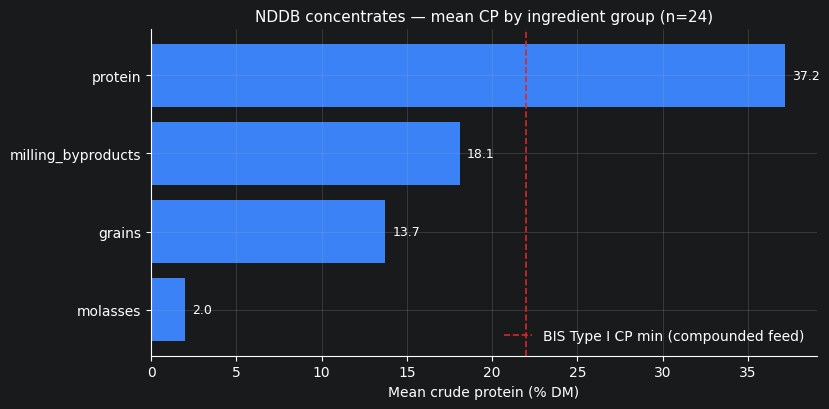

                      ingredient              group  cp_pct_dm  cf_pct_dm  me_mcal_kg
                   Cane molasses           molasses       2.00        NaN        2.60
                         Sorghum             grains       8.70       3.00        3.00
                           Maize             grains       9.00       2.00        3.10
                            Rice             grains       9.00      10.10        2.80
                           Wheat             grains      11.00       2.00        2.90
                            Oats             grains      11.00      15.50        2.60
                          Barley             grains      12.00       5.90        2.80
                           Bajra             grains      12.00       2.00        2.20
                     Rice polish milling_byproducts      14.00      12.00        2.70
                      Wheat bran milling_byproducts      16.00      15.00        2.70
            Rice bran (de-oiled) milling_byproducts   

In [4]:
group_cp = nddb_conc.groupby("group")["cp_pct_dm"].mean().sort_values()

fig, ax = plt.subplots()
bars = ax.barh(group_cp.index.astype(str), group_cp.values, color="#3b82f6")
ax.axvline(22, color="#dc2626", linestyle="--", linewidth=1.2, label="BIS Type I CP min (compounded feed)")
ax.set_xlabel("Mean crude protein (% DM)")
ax.set_title("NDDB concentrates — mean CP by ingredient group (n=24)")
ax.legend(loc="lower right")
for bar, val in zip(bars, group_cp.values):
    ax.text(val + 0.4, bar.get_y() + bar.get_height() / 2, f"{val:.1f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print(nddb_conc[["ingredient", "group", "cp_pct_dm", "cf_pct_dm", "me_mcal_kg"]].sort_values("cp_pct_dm").to_string(index=False))


Roughages (hays), n = 10


,ingredient,class,cp_pct_dm,ee_pct_dm,cf_pct_dm,ash_pct_dm,ndf_pct_dm,adf_pct_dm,me_mcal_kg
1,Wheat hay,hay,3.50,1.00,41.50,11.00,72.30,43.50,1.90
2,Maize hay,hay,3.60,0.80,33.20,10.50,62.20,37.40,2.10
7,Para grass hay,hay,5.30,2.00,34.60,12.30,64.40,30.40,1.70
3,Oats hay,hay,5.60,1.70,35.90,8.30,58.00,36.40,2.00
0,Sorghum hay,hay,7.00,1.20,38.90,8.50,56.50,40.30,1.90
8,Guinea grass hay,hay,7.60,1.20,38.10,16.00,60.50,39.70,1.70
9,Rhodes grass hay,hay,9.40,1.20,36.20,11.10,72.00,39.80,2.10
4,Cowpea hay,hay,15.00,1.10,34.80,13.30,54.00,48.00,1.80
6,Berseem hay,hay,15.00,6.60,30.60,12.10,49.60,50.40,2.40
5,Lucerne hay,hay,16.00,1.40,29.40,12.70,43.60,35.80,2.00


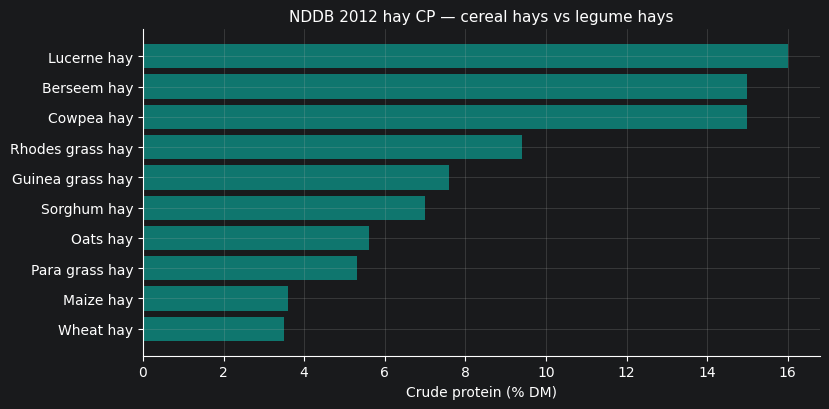

In [5]:
print("Roughages (hays), n =", len(nddb_rough))
display(nddb_rough.sort_values("cp_pct_dm"))

fig, ax = plt.subplots()
order = nddb_rough.sort_values("cp_pct_dm")
ax.barh(order.ingredient, order.cp_pct_dm, color="#0f766e")
ax.set_xlabel("Crude protein (% DM)")
ax.set_title("NDDB 2012 hay CP — cereal hays vs legume hays")
plt.tight_layout()
plt.show()


## 2. BIS IS 2052 — compounded-feed limits and typical ingredient AIA

IS 2052:2023 is the **pass/fail** standard for compounded cattle feed (not for a raw oilcake). Annex C of IS 2052:2009 gives **typical** ingredient composition, including acid-insoluble ash (sand/silica proxy).


In [6]:
bis_limits = load("bis_is2052_2023_compounded_feed_limits.csv")
annex = load("bis_is2052_2009_annex_c_ingredient_typical_composition.csv")

display(bis_limits)
print("Annex C ingredients:", len(annex))
display(annex.select_dtypes(include="number").describe().T)


,characteristic,unit,type_I,type_II,basis
0,Moisture,"% as-fed, max",11.00,11.00,as_fed
1,Crude protein,"% DM, min",22.00,20.00,moisture_free
2,Crude fat,"% DM, min",4.00,3.00,moisture_free
3,Crude fibre,"% DM, max",10.00,12.00,moisture_free
4,Acid insoluble ash,"% DM, max",2.50,3.00,moisture_free
5,Salt as NaCl,"% DM, max",1.00,1.00,moisture_free
6,Calcium,"% DM, min",0.80,0.80,moisture_free
7,Total phosphorus,"% DM, min",0.50,0.50,moisture_free
8,Available phosphorus,"% DM, min",0.25,0.25,moisture_free
9,Urea,"% DM, max",1.00,1.00,moisture_free


Annex C ingredients: 41


,count,mean,std,min,25%,50%,75%,max
moisture_pct,41.00,8.27,1.48,5.00,7.00,8.00,10.00,10.00
cp_pct,41.00,21.46,11.86,3.00,13.00,20.00,28.00,46.00
ee_pct,33.00,4.68,3.43,0.50,2.00,4.00,6.00,16.00
cf_pct,41.00,13.41,10.23,1.00,8.00,11.00,16.00,48.00
aia_pct,41.00,1.71,1.53,0.20,0.50,1.00,2.00,5.00


Ingredients whose *typical* AIA already exceeds Type I 2.5%: 8


,ingredient,category,cp_pct,aia_pct
12,Moth chuni,byproducts,13.00,5.00
14,Rice bran,byproducts,13.00,5.00
15,Deoiled rice bran,byproducts,15.00,5.00
17,Gram husk,byproducts,6.00,5.00
40,Bijda cake,waste,26.00,5.00
9,Arhar chuni,byproducts,18.00,4.00
31,Tapioca thippi,oilcakes,3.00,4.00
37,Ambadi oil cake,waste,22.00,3.00


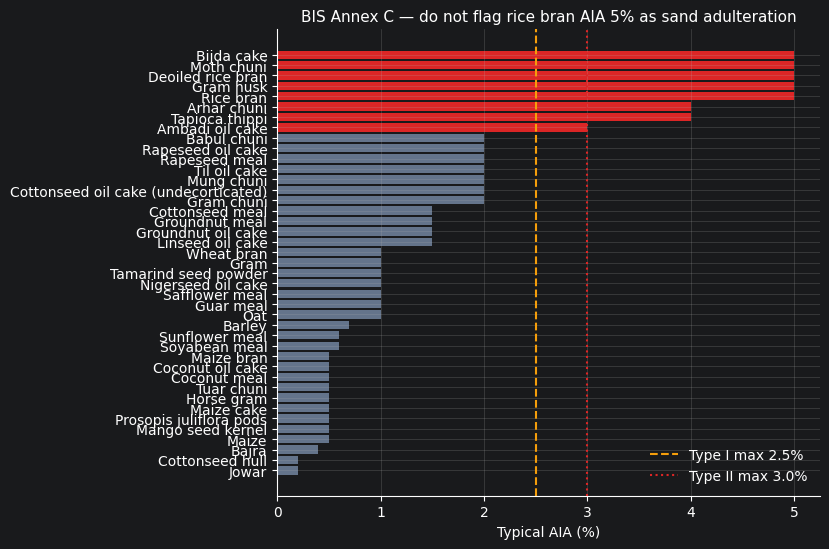

In [7]:
TYPE_I_AIA = 2.5
TYPE_II_AIA = 3.0

high_aia = annex.loc[annex.aia_pct > TYPE_I_AIA, ["ingredient", "category", "cp_pct", "aia_pct"]].sort_values(
    "aia_pct", ascending=False
)
print(f"Ingredients whose *typical* AIA already exceeds Type I {TYPE_I_AIA}%: {len(high_aia)}")
display(high_aia)

fig, ax = plt.subplots(figsize=(8.4, 5.6))
order = annex.sort_values("aia_pct")
colors = np.where(order.aia_pct > TYPE_I_AIA, "#dc2626", "#64748b")
ax.barh(order.ingredient, order.aia_pct, color=colors)
ax.axvline(TYPE_I_AIA, color="#f59e0b", linestyle="--", label="Type I max 2.5%")
ax.axvline(TYPE_II_AIA, color="#dc2626", linestyle=":", label="Type II max 3.0%")
ax.set_xlabel("Typical AIA (%)")
ax.set_title("BIS Annex C — do not flag rice bran AIA 5% as sand adulteration")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


**Product rule:** AIA must be **ingredient-conditional**. Rice bran, DORB, gram husk and moth chuni sit at 5% AIA as typical composition (plant silica). The same 5% on groundnut cake is not typical (Annex C GNC AIA = 1.5%).


## 3. Regional Indian composition — Bihar, NW Himalaya, IGFRI feeds

Same named ingredient, different tables. The app should show a **range**, not one NDDB number.


In [8]:
dey = load("dey_2014_bihar_feed_composition.csv")
kannan = load("kannan_2017_nw_himalayan_concentrates.csv")
singh = load("singh_2016_indian_energy_protein_feeds.csv")

# Singh reports g/kg DM — convert to % for comparison.
singh = singh.copy()
for col in [c for c in singh.columns if c.endswith("_g_kg_dm")]:
    singh[col.replace("_g_kg_dm", "_pct_dm")] = singh[col] / 10.0

print("Dey 2014 Bihar — CP by category")
display(dey.groupby("category")["cp_pct_dm"].agg(["count", "mean", "min", "max"]).round(2))
display(dey.sort_values("cp_pct_dm"))


Dey 2014 Bihar — CP by category


,count,mean,min,max
category,,,,
byproducts,4,13.35,9.88,15.32
crop_residue,10,6.72,2.94,13.05
grains,4,11.42,8.38,18.20
oilcakes,3,31.68,30.80,32.68
other,2,6.75,5.04,8.46


,feed,category,dm_pct,cp_pct_dm,cf_pct_dm,ee_pct_dm,om_pct_dm
3,Maize cobs,crop_residue,92.89,2.94,36.80,0.75,94.17
2,Maize stover,crop_residue,93.10,3.24,33.17,0.85,90.86
1,Wheat straw,crop_residue,91.88,3.26,32.27,0.98,89.04
0,Paddy straw,crop_residue,88.91,3.34,34.40,0.79,82.32
6,Mustard bhusa,crop_residue,92.78,4.68,41.50,1.31,90.24
21,Sugarcane tops,other,37.43,5.04,32.98,2.70,92.40
4,Lentil bhusa,crop_residue,91.76,8.10,35.95,1.24,83.25
11,Rice grit,grains,92.82,8.38,1.10,1.00,97.95
22,Local grass,other,34.50,8.46,27.43,1.70,87.90
5,Gram bhusa,crop_residue,90.60,8.48,39.50,1.14,89.77


In [9]:
print("Kannan 2017 NW Himalaya concentrates")
display(kannan.sort_values("cp_pct_dm"))

print("Singh 2016 IGFRI (converted to % DM)")
display(
    singh[
        ["feed", "class", "cp_pct_dm", "ee_pct_dm", "ndf_pct_dm", "adf_pct_dm", "lignin_pct_dm"]
    ].sort_values("cp_pct_dm")
)


Kannan 2017 NW Himalaya concentrates


,feed,class,om_pct_dm,cp_pct_dm,ee_pct_dm,ndf_pct_dm,adf_pct_dm,lignin_pct_dm
3,Broken rice,Energy,98.90,8.80,1.98,23.20,11.14,0.98
2,Jowar,Energy,97.37,8.81,2.72,18.42,6.33,1.53
0,Maize,Energy,97.86,9.29,4.07,18.19,5.25,1.33
1,Wheat,Energy,97.81,11.14,2.17,21.48,6.10,1.53
6,Rice polish,Energy,87.11,13.11,13.76,39.40,21.67,6.94
5,Deoiled rice bran,Energy,87.26,14.84,0.65,50.65,21.60,5.77
4,Wheat bran,Energy,94.19,15.29,3.24,53.14,14.54,3.16
8,Mustard cake,Protein,94.55,37.10,7.88,24.52,15.73,3.33
9,Deoiled mustard cake,Protein,91.67,37.31,0.83,38.75,20.82,3.22
11,Groundnut cake,Protein,93.86,42.11,7.95,25.20,17.57,3.41


Singh 2016 IGFRI (converted to % DM)


,feed,class,cp_pct_dm,ee_pct_dm,ndf_pct_dm,adf_pct_dm,lignin_pct_dm
1,Chickpea husk,Energy,4.50,0.59,67.20,64.80,5.55
4,Rice bran,Energy,7.01,4.56,66.80,52.30,12.80
3,Oat grain,Energy,9.64,5.23,35.10,15.60,1.25
2,Maize grain,Energy,9.91,4.77,36.40,6.18,1.55
0,Barley grain,Energy,10.30,1.52,41.40,15.70,2.30
7,Wheat grain,Energy,11.70,1.42,31.90,4.36,0.76
5,Wheat bran A,Energy,13.20,2.71,56.00,17.40,3.98
6,Wheat bran B,Energy,15.40,3.49,39.90,12.10,3.14
9,Cotton seed cake,Protein,24.00,7.20,51.70,36.50,10.00
8,Coconut cake,Protein,25.40,6.13,59.60,22.80,3.89


,Maize,Wheat bran,Rice bran,DORB,Mustard cake,Soybean meal,Groundnut cake
NDDB 2012,9.00,16.00,NaN,17.00,NaN,53.00,40.00
Dey 2014 Bihar,9.80,14.70,9.90,15.30,30.80,NaN,NaN
Kannan 2017 Himalaya,9.30,15.30,NaN,14.80,37.10,45.20,42.10
Singh 2016 IGFRI,9.90,13.20,7.00,NaN,34.80,NaN,33.20
BIS Annex C typical,9.00,15.00,13.00,15.00,NaN,45.00,42.00


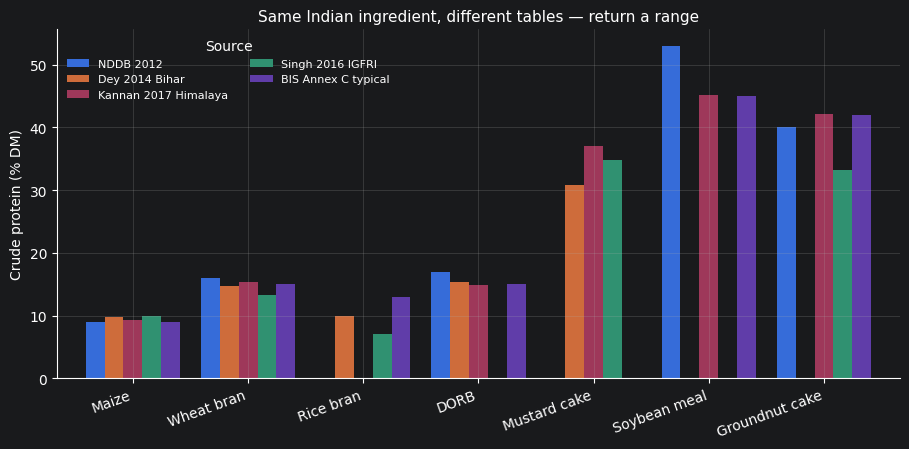

In [10]:
def first_cp(df, name_col, val_col, equals=None, contains=None, exclude=None) -> float:
    # Explicit match rules so mustard bhusa and DORB are not silently mixed in.
    lower = df[name_col].str.lower().str.strip()
    mask = pd.Series(False, index=df.index)
    if equals:
        mask |= lower.isin([s.lower() for s in equals])
    if contains:
        for needle in contains:
            mask |= lower.str.contains(needle.lower(), regex=False)
    if exclude:
        for needle in exclude:
            mask &= ~lower.str.contains(needle.lower(), regex=False)
    hit = df.loc[mask, val_col]
    return float(hit.iloc[0]) if len(hit) else np.nan


SPECS = {
    "Maize": dict(equals=["maize", "maize grain"]),
    "Wheat bran": dict(contains=["wheat bran"]),
    "Rice bran": dict(equals=["rice bran"]),
    "DORB": dict(contains=["deoiled rice", "de-oiled"]),
    "Mustard cake": dict(contains=["mustard cake", "mustard seed cake"], exclude=["bhusa", "deoiled"]),
    "Soybean meal": dict(contains=["soybean meal", "soyabean meal"]),
    "Groundnut cake": dict(contains=["groundnut oil cake", "groundnut cake"], exclude=["meal"]),
}

tables = [
    ("NDDB 2012", nddb_conc, "ingredient", "cp_pct_dm"),
    ("Dey 2014 Bihar", dey, "feed", "cp_pct_dm"),
    ("Kannan 2017 Himalaya", kannan, "feed", "cp_pct_dm"),
    ("Singh 2016 IGFRI", singh, "feed", "cp_pct_dm"),
    ("BIS Annex C typical", annex, "ingredient", "cp_pct"),
]

cross = pd.DataFrame(
    {
        src: {col: first_cp(df, name_col, val_col, **spec) for col, spec in SPECS.items()}
        for src, df, name_col, val_col in tables
    }
).T

display(cross.round(1))

fig, ax = plt.subplots(figsize=(9.2, 4.6))
cross.T.plot(kind="bar", ax=ax, width=0.82)
ax.set_ylabel("Crude protein (% DM)")
ax.set_title("Same Indian ingredient, different tables — return a range")
ax.set_xlabel("")
ax.legend(title="Source", ncols=2, fontsize=8)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 4. Silage — Punjab farmer pits and experimental cultivars

Kaur et al. 2026 is a **percentile summary for n=100**, not 100 raw rows. Do not fit a distribution and pretend it is sample-level data.

Flieg (from ICAR TMR silage work):

\[
\mathrm{Flieg} = 220 + (2 \times \mathrm{DM\%} - 15) - 40 \times \mathrm{pH}
\]


In [11]:
kaur = load("kaur_2026_punjab_farmer_silage_summary_n100.csv")
hundal = load("hundal_2020_wheat_silage.csv")
brar = load("brar_2021_punjab_maize_cultivar_silage.csv")
flieg_rules = load("flieg_score_rules.csv")

display(kaur)
display(flieg_rules)


,parameter,unit,n,mean,sd,min,q1,median,q3,max
0,DM,%,100,29.52,1.30,26.25,28.65,29.48,30.35,32.65
1,pH,pH,100,4.34,0.93,3.10,3.61,3.99,4.90,7.47
2,CP,%,100,9.36,0.88,6.57,8.69,9.36,9.88,11.37
3,Lactic acid,%,100,4.34,0.58,2.83,4.04,4.30,4.61,6.52
4,NH3N,%,100,9.82,2.30,5.12,7.96,9.67,11.79,14.70
5,Fleig Point,score,100,90.58,36.82,-34.10,68.40,104.10,116.80,142.80


,min_score,max_score,class,advice
0,81,1000,very_good,Good fermentation. Feed normally and keep silo...
1,61,80,good,Acceptable quality. Use soon and avoid heating...
2,41,60,satisfactory,Fair quality. Mix with better forage if animal...
3,21,40,moderate,Poor fermentation. Limit feeding and check for...
4,-1000,20,poor,Reject or get a lab test. High pH or low DM risk.


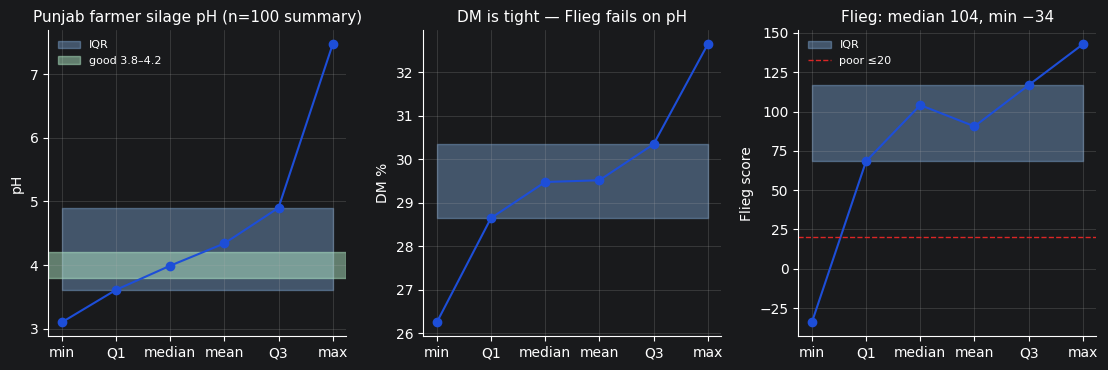

Takeaway: median pH 3.99 is in-band, but Q3=4.90 and max=7.47. About one in four pits is already above 4.9. A pocket pH meter is the high-leverage sensor.


In [12]:
def plot_percentile_bar(ax, row, ylabel, good_band=None):
    xs = ["min", "Q1", "median", "mean", "Q3", "max"]
    ys = [row["min"], row["q1"], row["median"], row["mean"], row["q3"], row["max"]]
    idx = np.arange(len(xs))
    ax.plot(idx, ys, marker="o", color="#1d4ed8")
    ax.fill_between(idx, row["q1"], row["q3"], color="#93c5fd", alpha=0.35, label="IQR")
    if good_band:
        ax.axhspan(good_band[0], good_band[1], color="#bbf7d0", alpha=0.45, label=f"good {good_band[0]}–{good_band[1]}")
    ax.set_xticks(idx, xs)
    ax.set_ylabel(ylabel)


ph = kaur.loc[kaur.parameter == "pH"].iloc[0]
dm = kaur.loc[kaur.parameter == "DM"].iloc[0]
flieg = kaur.loc[kaur.parameter.str.contains("Fleig|Flieg", case=False)].iloc[0]

fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.8))
plot_percentile_bar(axes[0], ph, "pH", good_band=(3.8, 4.2))
axes[0].set_title("Punjab farmer silage pH (n=100 summary)")
axes[0].legend(fontsize=8)
plot_percentile_bar(axes[1], dm, "DM %")
axes[1].set_title("DM is tight — Flieg fails on pH")
plot_percentile_bar(axes[2], flieg, "Flieg score")
axes[2].axhline(20, color="#dc2626", linestyle="--", linewidth=1, label="poor ≤20")
axes[2].set_title("Flieg: median 104, min −34")
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(
    "Takeaway: median pH {:.2f} is in-band, but Q3={:.2f} and max={:.2f}. "
    "About one in four pits is already above 4.9. A pocket pH meter is the high-leverage sensor.".format(
        ph["median"], ph["q3"], ph["max"]
    )
)


Hundal 2020 wheat silage (reported Flieg)


,cultivar,stage,pH,flieg_score,cp_pct_dm,tdn_pct,lactic_acid_pct_dm
0,PBW 343,Head,4.15,100.70,8.06,57.80,6.44
1,PBW 343,Milk,4.42,87.00,7.72,59.60,6.28
2,HD 3086,Head,4.25,105.20,8.51,62.40,6.26
3,HD 3086,Milk,4.41,52.90,7.25,62.50,6.04
4,HD 2967,Head,4.38,90.10,8.80,62.67,6.09
5,HD 2967,Milk,4.41,52.80,7.12,62.70,5.13
6,PBW 725,Head,4.24,105.60,9.70,63.70,6.01
7,PBW 725,Milk,4.27,103.00,8.33,63.60,5.70


Brar 2021 maize silage — Flieg computed from pH + DM


,cultivar,pH,dm_pct,cp_pct_dm,lactic_acid_pct_dm,flieg_computed,flieg_class
0,J 1006,4.38,21.90,5.55,6.50,73.60,good
1,PMH 10,4.10,19.53,8.44,8.30,80.06,good
2,DKC 9108,4.29,22.47,8.15,7.17,78.34,good


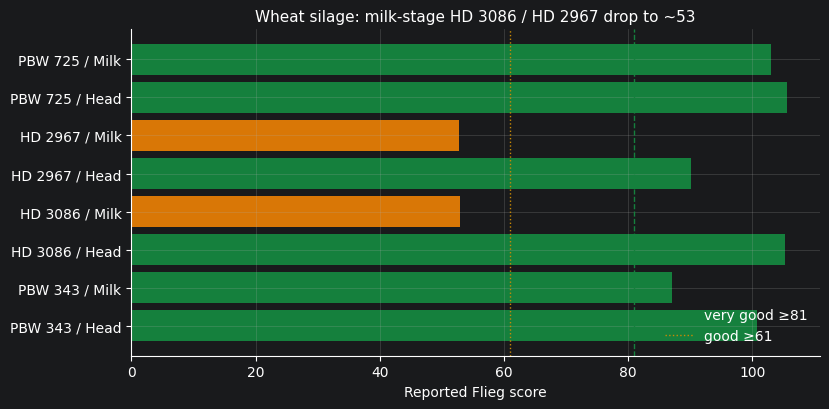

In [13]:
def flieg_score(dm_pct: float, pH: float) -> float:
    return 220 + (2 * dm_pct - 15) - 40 * pH


def flieg_class(score: float) -> str:
    # Integer CSV bands leave a 80–81 gap; classify from the published cut-points.
    if score >= 81:
        return "very_good"
    if score >= 61:
        return "good"
    if score >= 41:
        return "satisfactory"
    if score >= 21:
        return "moderate"
    return "poor"


brar = brar.copy()
brar["flieg_computed"] = flieg_score(brar.dm_pct, brar.pH)
brar["flieg_class"] = brar.flieg_computed.map(flieg_class)

print("Hundal 2020 wheat silage (reported Flieg)")
display(hundal[["cultivar", "stage", "pH", "flieg_score", "cp_pct_dm", "tdn_pct", "lactic_acid_pct_dm"]])

print("Brar 2021 maize silage — Flieg computed from pH + DM")
display(brar[["cultivar", "pH", "dm_pct", "cp_pct_dm", "lactic_acid_pct_dm", "flieg_computed", "flieg_class"]])

fig, ax = plt.subplots()
labels = hundal.cultivar + " / " + hundal.stage
ax.barh(labels, hundal.flieg_score, color=np.where(hundal.flieg_score >= 81, "#15803d", "#d97706"))
ax.axvline(81, color="#15803d", linestyle="--", linewidth=1, label="very good ≥81")
ax.axvline(61, color="#ca8a04", linestyle=":", linewidth=1, label="good ≥61")
ax.set_xlabel("Reported Flieg score")
ax.set_title("Wheat silage: milk-stage HD 3086 / HD 2967 drop to ~53")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 5. Urea adulteration — 4-DMAB yellow area (Anitha 2022)

Tiny experimental table (3 oilseed cakes × 3 doses). Enough to defend a **phone colorimetry demo**, not a huge image-net model. BIS compounded-feed urea maximum is **1% (10 g/kg)** when urea is a declared ingredient.


,oilseed_cake,urea_g_per_kg,yellow_area_pct_mean,yellow_area_pct_se
0,Soyabean meal,1,6.66,0.48
1,Soyabean meal,5,29.99,0.94
2,Soyabean meal,10,59.58,0.64
3,Groundnut cake,1,7.35,0.50
4,Groundnut cake,5,32.35,0.95
5,Groundnut cake,10,63.60,0.98
6,Un-decorticated cottonseed cake,1,8.19,0.84
7,Un-decorticated cottonseed cake,5,34.00,0.79
8,Un-decorticated cottonseed cake,10,67.35,0.89


oilseed_cake,Groundnut cake,Soyabean meal,Un-decorticated cottonseed cake
urea_g_per_kg,,,
1,7.35,6.66,8.19
5,32.35,29.99,34.00
10,63.60,59.58,67.35


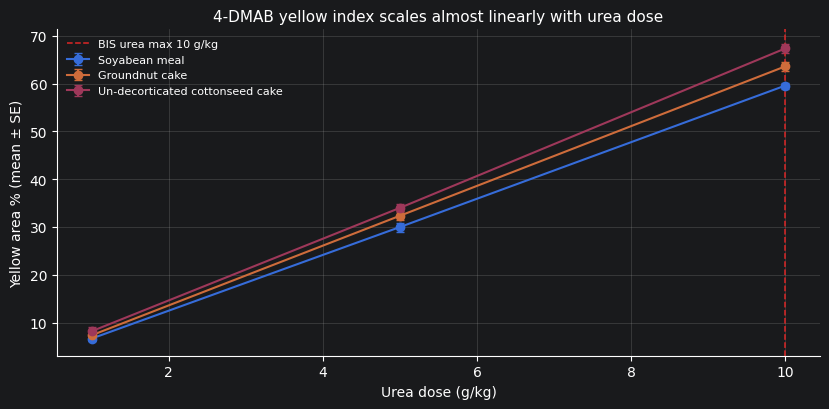

Visible at 1 g/kg (~7% yellow). Demo with spiked cakes at 0 / 1 / 5 / 10 g/kg.


In [14]:
urea = load("anitha_2022_urea_foldscope_yellow_area.csv")
display(urea)

pivot = urea.pivot(index="urea_g_per_kg", columns="oilseed_cake", values="yellow_area_pct_mean")
display(pivot)

fig, ax = plt.subplots()
for cake in urea.oilseed_cake.unique():
    sub = urea[urea.oilseed_cake == cake]
    ax.errorbar(
        sub.urea_g_per_kg,
        sub.yellow_area_pct_mean,
        yerr=sub.yellow_area_pct_se,
        marker="o",
        capsize=3,
        label=cake,
    )
ax.axvline(10, color="#dc2626", linestyle="--", linewidth=1.1, label="BIS urea max 10 g/kg")
ax.set_xlabel("Urea dose (g/kg)")
ax.set_ylabel("Yellow area % (mean ± SE)")
ax.set_title("4-DMAB yellow index scales almost linearly with urea dose")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Visible at 1 g/kg (~7% yellow). Demo with spiked cakes at 0 / 1 / 5 / 10 g/kg.")


## 6. Aflatoxin B1 — Kotinagu 2015 (AP + Telangana)

Means and incidence only. **Do not predict ppb from a phone photo.** BIS AFB1 maximum is **20 µg/kg**. Use this table for a **risk flag** (maize / groundnut cake / monsoon / mould).


,item,group,n_analyzed,n_positive,incidence_pct,mean_ppb,range_ppb,over_bis
0,Cattle feed,compound,24,6,26.00,32.00,20-60,True
1,Poultry feed,compound,17,6,35.20,13.40,10-20,False
2,Cotton seed cake,ingredient,7,3,42.80,23.30,10-40,True
3,Groundnut cake,ingredient,5,3,60.00,23.30,20-30,True
4,Soyabean cake,ingredient,3,1,33.30,50.00,NaN,True
5,Maize,ingredient,13,5,38.40,62.00,NaN,True
6,Wheat bran,ingredient,2,0,0.00,NaN,NaN,False
7,Deoiled rice bran,ingredient,4,0,0.00,NaN,NaN,False


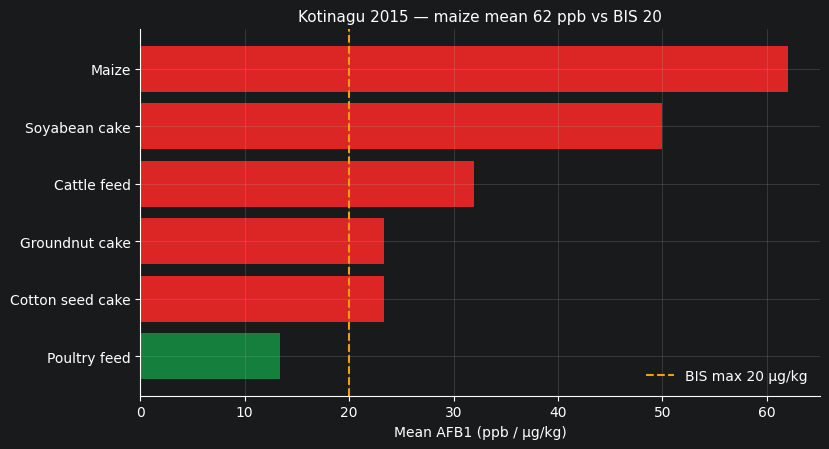

Cattle feed mean 32 ppb; maize 62; GNC 23.3. Wheat bran and DORB had 0 positives in this small sample — not a safety certificate.


In [15]:
afb1 = load("kotinagu_2015_afb1_ap_telangana.csv")
BIS_AFB1 = 20.0
afb1 = afb1.copy()
afb1["over_bis"] = afb1.mean_ppb > BIS_AFB1
display(afb1)

plot_df = afb1.dropna(subset=["mean_ppb"]).sort_values("mean_ppb")
fig, ax = plt.subplots(figsize=(8.4, 4.6))
colors = np.where(plot_df.mean_ppb > BIS_AFB1, "#dc2626", "#15803d")
ax.barh(plot_df.item, plot_df.mean_ppb, color=colors)
ax.axvline(BIS_AFB1, color="#f59e0b", linestyle="--", label="BIS max 20 µg/kg")
ax.set_xlabel("Mean AFB1 (ppb / µg/kg)")
ax.set_title("Kotinagu 2015 — maize mean 62 ppb vs BIS 20")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(
    "Cattle feed mean {:.0f} ppb; maize {:.0f}; GNC {:.1f}. "
    "Wheat bran and DORB had 0 positives in this small sample — not a safety certificate.".format(
        float(afb1.loc[afb1.item == "Cattle feed", "mean_ppb"].iloc[0]),
        float(afb1.loc[afb1.item == "Maize", "mean_ppb"].iloc[0]),
        float(afb1.loc[afb1.item == "Groundnut cake", "mean_ppb"].iloc[0]),
    )
)


## 7. Advisory rules already encoded for the prototype


In [16]:
rules = load("farmer_advisory_rules.csv")
display(rules)


,rule_id,module,condition,action
0,SILAGE_PH_DM,silage,compute Flieg = 220 + (2*DM_pct - 15) - 40*pH,Use flieg_score_rules.csv class
1,SILAGE_HIGH_PH,silage,pH > 4.2 and DM_pct < 30,Flag poor fermentation even before Flieg
2,FEED_LOOKUP,nutrient,farmer selects ingredient,"Return NDDB/BIS/Dey typical CP, CF, EE, ash, T..."
3,COMPOUND_BIS,nutrient,sample is compounded cattle feed,"Compare moisture, CP, fat, CF, AIA against IS ..."
4,UREA_DMAB,adulteration,4-DMAB yellow on oilcake,Suspect urea; BIS max 1% if urea is declared
5,AIA_SAND,adulteration,AIA above 2.5% (Type I) or 3.0% (Type II),Possible sand/silica contamination
6,MOULD_MOISTURE,mould,visible mould or moisture high in store,Do not claim ppb; advise reject or lab AFB1 test
7,AFB1_RISK,mycotoxin,"maize or groundnut cake, monsoon, poor storage",High-risk ingredient; BIS AFB1 max 20 ug/kg


## 8. Implications for the SIH prototype

Findings that change the product, not just the slides:


In [17]:
findings = pd.DataFrame(
    [
        {
            "finding": "Oilcakes vs grains: ~20+ CP points (NDDB means 37% vs 14%)",
            "product_rule": "Ingredient ID is most of nutrient prediction without NIR.",
        },
        {
            "finding": "Mustard cake CP 30.8% (Bihar) vs 37.1% (Himalaya) vs 34.8% (IGFRI)",
            "product_rule": "Show a range, never one decimal from a camera.",
        },
        {
            "finding": "8/41 Annex C ingredients already have typical AIA > Type I 2.5%",
            "product_rule": "AIA / sand logic must be ingredient-conditional.",
        },
        {
            "finding": "Punjab silage DM tight (26–33%); pH Q3=4.90, max=7.47, Flieg min=−34",
            "product_rule": "Lead with pocket pH + Flieg. Moisture is supporting.",
        },
        {
            "finding": "4-DMAB yellow ~7 / 32 / 63% at 1 / 5 / 10 g urea per kg",
            "product_rule": "Phone colorimetry is a defensible urea demo vs BIS 1%.",
        },
        {
            "finding": "Maize mean AFB1 62 ppb vs BIS 20 in Kotinagu (small n)",
            "product_rule": "Monsoon maize/GNC = high-risk advisory; never RGB→ppb.",
        },
        {
            "finding": "No public raw national Indian feed/silage CSV",
            "product_rule": "Do not claim a trained national CP or aflatoxin model.",
        },
    ]
)
display(findings)


,finding,product_rule
0,Oilcakes vs grains: ~20+ CP points (NDDB means...,Ingredient ID is most of nutrient prediction w...
1,Mustard cake CP 30.8% (Bihar) vs 37.1% (Himala...,"Show a range, never one decimal from a camera."
2,8/41 Annex C ingredients already have typical ...,AIA / sand logic must be ingredient-conditional.
3,"Punjab silage DM tight (26–33%); pH Q3=4.90, m...",Lead with pocket pH + Flieg. Moisture is suppo...
4,4-DMAB yellow ~7 / 32 / 63% at 1 / 5 / 10 g ur...,Phone colorimetry is a defensible urea demo vs...
5,Maize mean AFB1 62 ppb vs BIS 20 in Kotinagu (...,Monsoon maize/GNC = high-risk advisory; never ...
6,No public raw national Indian feed/silage CSV,Do not claim a trained national CP or aflatoxi...


### Honesty checklist before the SIH demo

- Kaur n=100 is **percentiles**, not raw pit-level rows.
- Anitha urea n is tiny (3 cakes × 3 doses). Spike your own cakes for the live demo.
- Kotinagu AFB1 means are **not** a national prevalence survey.
- GrainSet maize images and milk-urea SOPs are **out of scope** for training cattle-feed models.
- Collect this weekend if you can: 20–40 oilcakes at 0/1/5/10 g urea per kg, ~20 silage pH+moisture readings, ~20 clean vs mouldy pit photos.
